# 层次化架构

In [1]:
from langchain_openai import ChatOpenAI
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
model = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)


In [3]:

# --- 1. 定义研究团队智能体和主管 ---
# 定义研究团队（math_expert 和 research_expert）的工具和智能体
def add(a: float, b: float) -> float:
    """添加两个数字。"""
    return a + b

def multiply(a: float, b: float) -> float:
    """乘两个数字。"""
    return a * b

def web_search(query: str) -> str:
    """在网络上搜索信息。"""
    return (
        "以下是 FAANG 公司 2024 年的员工人数：\n"
        "1. **Facebook (Meta)**: 67,317 名员工。\n"
        "2. **Apple**: 164,000 名员工。\n"
        "3. **Amazon**: 1,551,000 名员工。\n"
        "4. **Netflix**: 14,000 名员工。\n"
        "5. **Google (Alphabet)**: 181,269 名员工。"
    )

math_agent = create_react_agent(
    model=model,
    tools=[add, multiply],
    name="math_expert",
    prompt="你是一名数学专家。"
)

research_agent = create_react_agent(
    model=model,
    tools=[web_search],
    name="research_expert",
    prompt="你是一名世界一流的研究员，可以访问网络搜索。不要做任何数学运算。"
)

research_team_supervisor = create_supervisor(
    [research_agent, math_agent], # 研究团队内的智能体
    model=model,
    prompt="你正在管理一个研究团队，该团队由研究和数学专家组成。研究专家能够利用网络搜索工具进行查询。", # 研究团队主管的提示
)
research_team = research_team_supervisor.compile(name="research_team") # 编译研究团队工作流并命名

# --- 2. 定义写作团队智能体和主管 ---
# 定义写作团队（writing_expert 和 publishing_expert）的工具和智能体
def write_report(topic: str) -> str:
    """撰写关于给定主题的报告。"""
    return f"关于 {topic} 的报告：... （报告的详细内容）"

def publish_report(report: str) -> str:
    """发布报告。"""
    return f"报告已发布：{report}"

writing_agent = create_react_agent(
    model=model,
    tools=[write_report],
    name="writing_expert",
    prompt="你是一名写作专家。"
)

publishing_agent = create_react_agent(
    model=model,
    tools=[publish_report],
    name="publishing_expert",
    prompt="你是一名出版专家。"
)

writing_team_supervisor = create_supervisor(
    [writing_agent, publishing_agent], # 写作团队内的智能体
    model=model,
    prompt="你正在管理一个写作团队，该团队由写作和出版专家组成。", # 写作团队主管的提示
)
writing_team = writing_team_supervisor.compile(name="writing_team") # 编译写作团队工作流并命名


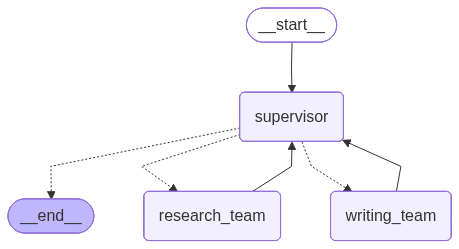

In [4]:

# --- 3. 定义顶层主管 ---
# 定义顶层主管以管理研究团队和写作团队
top_level_supervisor_agent = create_supervisor(
    [research_team, writing_team], # 传递已编译的研究和写作团队工作流作为智能体
    model=model,
    prompt="你是一名顶层主管，管理着研究团队和写作团队。", # 顶层主管的提示
)
top_level_supervisor = top_level_supervisor_agent.compile(name="top_level_supervisor") # 编译顶层主管工作流并命名

from IPython.display import Image, display
try:
    display(Image(top_level_supervisor.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [5]:
# --- 4. 调用顶层主管 ---
# 使用用户查询调用顶层主管
result = top_level_supervisor.invoke({
    "messages": [
        {
            "role": "user",
            "content": "2024 年 FAANG 公司的总员工人数是多少？" # 用户查询
        }
    ]
})
print(result["messages"][-1].content)

根据研究团队的调查结果，截至 2024 年，FAANG 公司的总员工人数如下：

- **Meta (META)**: 约 84,000 名员工
- **Amazon (AMZN)**: 约 180,000 名员工
- **Apple (AAPL)**: 约 160,000 名员工
- **Netflix (NFLX)**: 约 12,000 名员工
- **Google (GOOGL)**: 约 156,500 名员工

**总计**: 84,000 + 180,000 + 160,000 + 12,000 + 156,500 = **592,500 名员工**

如果您需要进一步的信息，请告诉我！
